<a href="https://colab.research.google.com/github/Boaz5/lol-champ-ml/blob/main/CS489_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import top_k_accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Data Processing




In [ ]:
from google.colab import drive
import glob

drive.mount('/content/drive/', force_remount=True)

DATA_DIR = "/content/drive/MyDrive/DeepLearning/LOL"

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

dfs = []
for file in csv_files:
    try:
        df = pd.read_csv(file)
        df["source_file"] = os.path.basename(file)
        dfs.append(df)
        print(f"Loaded {os.path.basename(file)}: {df.shape}")
    except Exception as e:
        print(f"Failed to load {file}: {e}")

full_df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", full_df.shape)
print(full_df.columns.tolist())

Mounted at /content/drive/
Loaded 2014_LoL_esports_match_data_from_OraclesElixir.csv: (11016, 166)
Loaded 2015_LoL_esports_match_data_from_OraclesElixir.csv: (21792, 166)
Loaded 2016_LoL_esports_match_data_from_OraclesElixir.csv: (50568, 166)
Loaded 2017_LoL_esports_match_data_from_OraclesElixir.csv: (68424, 166)
Loaded 2018_LoL_esports_match_data_from_OraclesElixir.csv: (80844, 166)
Loaded 2019_LoL_esports_match_data_from_OraclesElixir.csv: (97500, 166)
Loaded 2020_LoL_esports_match_data_from_OraclesElixir.csv: (117012, 166)
Loaded 2021_LoL_esports_match_data_from_OraclesElixir.csv: (148464, 166)


/tmp/ipykernel_4299/2292917733.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2022_LoL_esports_match_data_from_OraclesElixir.csv: (148980, 166)


/tmp/ipykernel_4299/2292917733.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2023_LoL_esports_match_data_from_OraclesElixir.csv: (133428, 166)


...

Loaded 2024_LoL_esports_match_data_from_OraclesElixir.csv: (122388, 166)


/tmp/ipykernel_4299/2292917733.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2025_LoL_esports_match_data_from_OraclesElixir.csv: (120636, 166)


/tmp/ipykernel_4299/2292917733.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2026_LoL_esports_match_data_from_OraclesElixir.csv: (43080, 166)
Combined shape: (1164132, 166)
['gameid', 'datacompleteness', 'url', 'league', 'year', 'split', 'playoffs', 'date', 'game', 'patch', 'participantid', 'side', 'position', 'playername', 'playerid', 'teamname', 'teamid', 'firstPick', 'champion', 'ban1', 'ban2', 'ban3', 'ban4', 'ban5', 'pick1', 'pick2', 'pick3', 'pick4', 'pick5', 'gamelength', 'result', 'kills', 'deaths', 'assists', 'teamkills', 'teamdeaths', 'doublekills', 'triplekills', 'quadrakills', 'pentakills', 'firstblood', 'firstbloodkill', 'firstbloodassist', 'firstbloodvictim', 'team kpm', 'ckpm', 'firstdragon', 'dragons', 'opp_dragons', 'elementaldrakes', 'opp_elementaldrakes', 'infernals', 'mountains', 'clouds', 'oceans', 'chemtechs', 'hextechs', 'dragons (type unknown)', 'elders', 'opp_elders', 'firstherald', 'heralds', 'opp_heralds', 'void_grubs', 'opp_void_grubs', 'firstbaron', 'barons', 'opp_barons', 'atakhans', 'opp_atakhans', 'firsttower', 'towers', '

Only keep matches that is complete/filtering incomplete datas

In [ ]:
# Filter the DataFrame to only keep rows where 'datacompleteness' column has 'complete'
original_rows = len(full_df)
# display(full_df[full_df['gameid'] == '218-247'].iloc[:20])
full_df = full_df[full_df['datacompleteness'] == 'complete'].copy()

print(f"Row Count before filtering for completeness: {original_rows}")
print(f"Row Count after filtering for completeness: {len(full_df)}")


Row Count before filtering for completeness: 1164132
Row Count after filtering for completeness: 1030944


In [ ]:

needed_cols = ['gameid', 'side', 'position', 'champion', 'patch', 'result']
df = full_df[needed_cols].copy()
df.dropna(subset=['champion'], inplace=True)
df.head()

# print(full_df.iloc[:20])

,gameid,side,position,champion,patch,result
0,TRLH3/33,Blue,top,Trundle,3.15,1
1,TRLH3/33,Blue,jng,Vi,3.15,1
2,TRLH3/33,Blue,mid,Orianna,3.15,1
3,TRLH3/33,Blue,bot,Jinx,3.15,1
4,TRLH3/33,Blue,sup,Annie,3.15,1


Cleaning up and Standardize data

In [ ]:
df['position'] = df['position'].astype(str).str.lower().str.strip()
df['side'] = df['side'].astype(str).str.lower().str.strip()
df['champion'] = df['champion'].astype(str).str.strip()

possible_positions = ['top', 'jng', 'mid', 'bot', 'sup', 'jungle', 'adc', 'support']
# print(df["position"].value_counts())
# print(df.loc[~df['position'].isin(possible_positions)])
df = df[df['position'].isin(possible_positions)].copy()

role_map = {
    'jng': 'jungle',
    'bot': 'adc',
    'sup': 'support'
}

# Help Standardized the role names as jungle, adc, and support is more commonly recognize
df['position'] = df['position'].replace(role_map)
print(df['position'].value_counts())
# print(df['side'].value_counts())


position
top        171824
jungle     171824
mid        171824
adc        171824
support    171824
Name: count, dtype: int64


Only keep valid matches that have 10 players exactly (just in case a match isnt valid)

In [ ]:
match_counts = df.groupby('gameid').size()
valid_matches = match_counts[match_counts == 10].index
df = df[df['gameid'].isin(valid_matches)].copy()

print("Rows:", len(df))
print("Unique matches:", df["gameid"].nunique())

Rows: 859120
Unique matches: 85912


Iterate to each player each game and extract info regarding the player's target_champion, their role, what patch the game is from, and result. Also store the list of other champions picked in the match

In [ ]:
samples = []

for gameid, group in df.groupby("gameid"):
    group_rows = group.reset_index(drop=True)
    champs = group_rows["champion"].tolist()

    for i in range(len(group_rows)):
        row = group_rows.iloc[i]
        other_champs = champs[:i] + champs[i+1:]

        samples.append({
            "gameid": gameid,
            "role": row["position"],
            "side": row["side"],
            "target_champion": row["champion"],
            "patch": row["patch"],
            "result": row["result"],
            "other_champions": other_champs
        })

samples_df = pd.DataFrame(samples)
print(samples_df.shape)
samples_df.head()

(859120, 7)


,gameid,role,side,target_champion,patch,result,other_champions
0,2899-3157,top,blue,Ornn,8.01,1,"[Kha'Zix, Orianna, Ezreal, Tahm Kench, Maokai,..."
1,2899-3157,jungle,blue,Kha'Zix,8.01,1,"[Ornn, Orianna, Ezreal, Tahm Kench, Maokai, Ja..."
2,2899-3157,mid,blue,Orianna,8.01,1,"[Ornn, Kha'Zix, Ezreal, Tahm Kench, Maokai, Ja..."
3,2899-3157,adc,blue,Ezreal,8.01,1,"[Ornn, Kha'Zix, Orianna, Tahm Kench, Maokai, J..."
4,2899-3157,support,blue,Tahm Kench,8.01,1,"[Ornn, Kha'Zix, Orianna, Ezreal, Maokai, Jarva..."


# Feature Engineering

These cells calculate historical winrates per champion and per champion's role combination, which are added as critical feature for the model

In [ ]:
samples_df['temp_original_idx'] = samples_df.index

# Sort by patch, gameid, and original_index to ensure correct 'historical' context
# This is crucial for calculating winrates strictly from *previous* games.
samples_df_sorted = samples_df.sort_values(by=['patch', 'gameid', 'temp_original_idx']).reset_index(drop=True)

# Calculate historical winrate using cumulative sum (expanding window)
# Group by champion, then apply expanding sum/count, and shift.

def calculate_cumulative_stats(group):
    group['wins_cumsum'] = group['result'].cumsum()
    group['games_cumcount'] = (group.index - group.index[0]) + 1 # Equivalent to cumcount + 1
    group['prev_wins_cumsum'] = group['wins_cumsum'].shift(1).fillna(0)
    group['prev_games_cumcount'] = group['games_cumcount'].shift(1).fillna(0)
    return group

samples_df_sorted = samples_df_sorted.groupby('target_champion', group_keys=False).apply(calculate_cumulative_stats)

# Calculate historical winrate
samples_df_sorted['historical_winrate'] = np.where(
    samples_df_sorted['prev_games_cumcount'] > 0,
    samples_df_sorted['prev_wins_cumsum'] / samples_df_sorted['prev_games_cumcount'],
    0.5 # Default to 0.5 (50%) for the first game of a champion or if no prior data
)

# Merge the new feature back to the original samples_df
# Ensure to drop the helper column 'temp_original_idx' and replace the old 'patch' if necessary.
samples_df = pd.merge(samples_df.drop(columns=['historical_winrate'] if 'historical_winrate' in samples_df.columns else []),
                      samples_df_sorted[['temp_original_idx', 'historical_winrate']],
                      on='temp_original_idx',
                      how='left').drop(columns='temp_original_idx')

print("Historical winrate feature added to samples_df.")
print(samples_df[['gameid', 'patch', 'target_champion', 'result', 'historical_winrate']].head())

/tmp/ipykernel_4299/3056259455.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples_df_sorted = samples_df_sorted.groupby('target_champion', group_keys=False).apply(calculate_cumulative_stats)


Historical winrate feature added to samples_df.
      gameid  patch target_champion  result  historical_winrate
0  2899-3157   8.01            Ornn       1            0.008772
1  2899-3157   8.01         Kha'Zix       1            0.006547
2  2899-3157   8.01         Orianna       1            0.008542
3  2899-3157   8.01          Ezreal       1            0.008693
4  2899-3157   8.01      Tahm Kench       1            0.005979


Add Historical winrate by Role

In [ ]:
# Store original index to merge back later, if samples_df was reset or re-created
samples_df['temp_original_idx_role'] = samples_df.index

# Sort by patch, gameid, role, and original_index to ensure correct 'historical' context
# for winrate per champion per role.
samples_df_sorted_role = samples_df.sort_values(by=['patch', 'gameid', 'role', 'temp_original_idx_role']).reset_index(drop=True)

# Calculate historical winrate using cumulative sum (expanding window) per champion-role combination
def calculate_cumulative_stats_role(group):
    group['wins_cumsum_role'] = group['result'].cumsum()
    group['games_cumcount_role'] = (group.index - group.index[0]) + 1
    group['prev_wins_cumsum_role'] = group['wins_cumsum_role'].shift(1).fillna(0)
    group['prev_games_cumcount_role'] = group['games_cumcount_role'].shift(1).fillna(0)
    return group

samples_df_sorted_role = samples_df_sorted_role.groupby(['target_champion', 'role'], group_keys=False).apply(calculate_cumulative_stats_role)

# Calculate historical role winrate
samples_df_sorted_role['historical_role_winrate'] = np.where(
    samples_df_sorted_role['prev_games_cumcount_role'] > 0,
    samples_df_sorted_role['prev_wins_cumsum_role'] / samples_df_sorted_role['prev_games_cumcount_role'],
    0.5 # Default to 0.5 (50%) for the first game of a champion in a role or if no prior data
)

# Merge the new feature back to the original samples_df
samples_df = pd.merge(samples_df.drop(columns=['historical_role_winrate'] if 'historical_role_winrate' in samples_df.columns else []), # Drop if already exists
                      samples_df_sorted_role[['temp_original_idx_role', 'historical_role_winrate']],
                      on='temp_original_idx_role',
                      how='left').drop(columns='temp_original_idx_role') # Drop the helper column

print("Historical role winrate feature added to samples_df.")
print(samples_df[['gameid', 'patch', 'target_champion', 'role', 'result', 'historical_winrate', 'historical_role_winrate']].head())

/tmp/ipykernel_4299/2093319164.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples_df_sorted_role = samples_df_sorted_role.groupby(['target_champion', 'role'], group_keys=False).apply(calculate_cumulative_stats_role)


Historical role winrate feature added to samples_df.
      gameid  patch target_champion     role  result  historical_winrate  \
0  2899-3157   8.01            Ornn      top       1            0.008772   
1  2899-3157   8.01         Kha'Zix   jungle       1            0.006547   
2  2899-3157   8.01         Orianna      mid       1            0.008542   
3  2899-3157   8.01          Ezreal      adc       1            0.008693   
4  2899-3157   8.01      Tahm Kench  support       1            0.005979   

   historical_role_winrate  
0                 0.008696  
1                 0.006498  
2                 0.008523  
3                 0.007853  
4                 0.005110  


# Prep Inputs for NN

In [ ]:
all_champions = sorted(df["champion"].unique().tolist())
champ_to_idx = {champ: i for i, champ in enumerate(all_champions)}
idx_to_champ = {i: champ for champ, i in champ_to_idx.items()}
num_champs = len(all_champions)

roles = sorted(df["position"].unique().tolist())
role_to_idx = {role: i for i, role in enumerate(roles)}

print("Number of champions:", num_champs)
print("Roles:", roles)

Number of champions: 172
Roles: ['adc', 'jungle', 'mid', 'support', 'top']


Build the inputs

In [ ]:
picked_ids = np.array(
    [[champ_to_idx[ch] for ch in champ_list]
     for champ_list in samples_df["other_champions"]]
, dtype=np.int32)

def one_hot_role(role, role_to_idx):
    vec = np.zeros(len(role_to_idx), dtype=np.float32)
    vec[role_to_idx[role]] = 1.0
    return vec

role_features_nn = np.vstack([
    one_hot_role(role, role_to_idx)
    for role in samples_df["role"]
]).astype(np.float32)

side_features_nn = samples_df["side"].map({"blue": 0, "red": 1}).to_numpy(dtype=np.float32).reshape(-1, 1)

# New feature: historical winrate and historical_role_winrate combined
winrate_features_nn = np.hstack([samples_df["historical_winrate"].to_numpy(dtype=np.float32).reshape(-1, 1),
                                 samples_df["historical_role_winrate"].to_numpy(dtype=np.float32).reshape(-1, 1)])

y_nn = samples_df["target_champion"].map(champ_to_idx).to_numpy(dtype=np.int32)

print("picked_ids shape:", picked_ids.shape)
print("role_features_nn shape:", role_features_nn.shape)
print("side_features_nn shape:", side_features_nn.shape)
print("winrate_features_nn shape:", winrate_features_nn.shape)
print("y_nn shape:", y_nn.shape)

picked_ids shape: (859120, 9)
role_features_nn shape: (859120, 5)
side_features_nn shape: (859120, 1)
winrate_features_nn shape: (859120, 2)
y_nn shape: (859120,)


Splitting based on match ID

In [ ]:
unique_matches = samples_df["gameid"].unique()

train_matches, temp_matches = train_test_split(unique_matches, test_size=0.30, random_state=42)
val_matches, test_matches = train_test_split(temp_matches, test_size=0.50, random_state=42)

train_mask = samples_df["gameid"].isin(train_matches).to_numpy()
val_mask = samples_df["gameid"].isin(val_matches).to_numpy()
test_mask = samples_df["gameid"].isin(test_matches).to_numpy()

picked_train = picked_ids[train_mask]
picked_val = picked_ids[val_mask]
picked_test = picked_ids[test_mask]

role_train = role_features_nn[train_mask]
role_val = role_features_nn[val_mask]
role_test = role_features_nn[test_mask]

side_train = side_features_nn[train_mask]
side_val = side_features_nn[val_mask]
side_test = side_features_nn[test_mask]

winrate_train = winrate_features_nn[train_mask]
winrate_val = winrate_features_nn[val_mask]
winrate_test = winrate_features_nn[test_mask]

y_train_nn = y_nn[train_mask]
y_val_nn = y_nn[val_mask]
y_test_nn = y_nn[test_mask]

print("Train shapes:", picked_train.shape, role_train.shape, side_train.shape, winrate_train.shape, y_train_nn.shape)
print("Val shapes:", picked_val.shape, role_val.shape, side_val.shape, winrate_val.shape, y_val_nn.shape)
print("Test shapes:", picked_test.shape, role_test.shape, side_test.shape, winrate_test.shape, y_test_nn.shape)

Train shapes: (601380, 9) (601380, 5) (601380, 1) (601380, 2) (601380,)
Val shapes: (128870, 9) (128870, 5) (128870, 1) (128870, 2) (128870,)
Test shapes: (128870, 9) (128870, 5) (128870, 1) (128870, 2) (128870,)


In [ ]:
def one_hot_labels(y, num_classes):
    y_onehot = np.zeros((len(y), num_classes), dtype=np.float32)
    y_onehot[np.arange(len(y)), y] = 1.0
    return y_onehot

def softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    return exp_vals / np.sum(exp_vals, axis=1, keepdims=True)

def compute_class_weights(y, num_classes):
    counts = np.bincount(y, minlength=num_classes)
    total = len(y)
    weights = total / (num_classes * np.maximum(counts, 1))
    return weights.astype(np.float32)

def weighted_cross_entropy_loss(probs, y_true, class_weights):
    n = len(y_true)
    correct_probs = probs[np.arange(n), y_true]
    weights = class_weights[y_true]
    return -np.mean(weights * np.log(correct_probs + 1e-12))

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(np.float32)

In [ ]:
def init_adam_state(param):
    return {
        "m": np.zeros_like(param, dtype=np.float32),
        "v": np.zeros_like(param, dtype=np.float32)
    }

def adam_update(param, grad, state, t, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    state["m"] = beta1 * state["m"] + (1 - beta1) * grad
    state["v"] = beta2 * state["v"] + (1 - beta2) * (grad ** 2)

    m_hat = state["m"] / (1 - beta1 ** t)
    v_hat = state["v"] / (1 - beta2 ** t)

    param -= lr * m_hat / (np.sqrt(v_hat) + eps)
    return param

In [ ]:
def init_embedding_nn(num_champs, num_roles, embed_dim=16, hidden_dim=64, seed=42):
    np.random.seed(seed)

    E = np.random.randn(num_champs, embed_dim).astype(np.float32) * 0.01

    # input_dim now includes embed_dim, num_roles (one-hot), side (1), AND historical_winrate (2)
    input_dim = embed_dim + num_roles + 1 + winrate_train.shape[1] # Use shape[1] for flexible winrate features

    W1 = np.random.randn(input_dim, hidden_dim).astype(np.float32) * np.sqrt(2.0 / input_dim)
    b1 = np.zeros((1, hidden_dim), dtype=np.float32)

    W2 = np.random.randn(hidden_dim, num_champs).astype(np.float32) * np.sqrt(2.0 / hidden_dim)
    b2 = np.zeros((1, num_champs), dtype=np.float32)

    params = {
        "E": E,
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }

    adam_states = {name: init_adam_state(param) for name, param in params.items()}
    return params, adam_states

In [ ]:
def forward_embedding_nn(picked_ids_batch, role_batch, side_batch, winrate_batch, params):
    E = params["E"]
    W1 = params["W1"]
    b1 = params["b1"]
    W2 = params["W2"]
    b2 = params["b2"]

    embedded = E[picked_ids_batch]
    draft_embed = embedded.mean(axis=1)

    # Concatenate all input features
    X_input = np.hstack([draft_embed, role_batch, side_batch, winrate_batch])

    z1 = X_input @ W1 + b1
    h1 = relu(z1)

    logits = h1 @ W2 + b2
    probs = softmax(logits)

    cache = {
        "embedded": embedded,
        "draft_embed": draft_embed,
        "X_input": X_input,
        "z1": z1,
        "h1": h1,
        "logits": logits,
        "probs": probs
    }

    return probs, cache

In [ ]:
def backward_embedding_nn(picked_ids_batch, role_batch, side_batch, winrate_batch, y_batch, class_weights, params, cache):
    E = params["E"]
    W1 = params["W1"]
    W2 = params["W2"]

    X_input = cache["X_input"]
    z1 = cache["z1"]
    h1 = cache["h1"]
    probs = cache["probs"]

    batch_size = len(y_batch)
    num_classes = probs.shape[1]
    num_picks = picked_ids_batch.shape[1]

    y_onehot = one_hot_labels(y_batch, num_classes)
    sample_weights = class_weights[y_batch].reshape(-1, 1)

    dlogits = (probs - y_onehot) * sample_weights
    dlogits /= batch_size

    dW2 = h1.T @ dlogits
    db2 = np.sum(dlogits, axis=0, keepdims=True)

    dh1 = dlogits @ W2.T
    dz1 = dh1 * relu_grad(z1)

    dW1 = X_input.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    dX_input = dz1 @ W1.T

    embed_dim = E.shape[1]
    # Extract gradient for draft_embed (first embed_dim columns of dX_input)
    ddraft_embed = dX_input[:, :embed_dim]

    # Distribute gradient back to individual champion embeddings
    dembedded = np.repeat(ddraft_embed[:, np.newaxis, :] / num_picks, num_picks, axis=1)

    # Accumulate gradients for E
    dE = np.zeros_like(E, dtype=np.float32)
    np.add.at(dE, picked_ids_batch, dembedded)

    grads = {
        "E": dE,
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2
    }

    return grads

In [ ]:
def predict_proba_embedding_nn(picked_ids_arr, role_arr, side_arr, winrate_arr, params):
    probs, _ = forward_embedding_nn(picked_ids_arr, role_arr, side_arr, winrate_arr, params)
    return probs

def predict_embedding_nn(picked_ids_arr, role_arr, side_arr, winrate_arr, params):
    probs = predict_proba_embedding_nn(picked_ids_arr, role_arr, side_arr, winrate_arr, params)
    return np.argmax(probs, axis=1)

In [ ]:
def train_embedding_nn(
    picked_train, role_train, side_train, winrate_train, y_train,
    picked_val, role_val, side_val, winrate_val, y_val,
    num_champs, num_roles,
    embed_dim=16,
    hidden_dim=64,
    learning_rate=0.001,
    epochs=20,
    batch_size=32,
    use_class_weights=True,
    seed=42
):
    params, adam_states = init_embedding_nn(
        num_champs=num_champs,
        num_roles=num_roles,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        seed=seed
    )

    class_weights = (
        compute_class_weights(y_train, num_champs)
        if use_class_weights
        else np.ones(num_champs, dtype=np.float32)
    )

    n_samples = len(y_train)
    t = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_top1": [],
        "val_macro_f1": [],
        "val_top3": [],
        "val_top5": []
    }

    for epoch in range(epochs):
        indices = np.random.permutation(n_samples)

        picked_train_shuf = picked_train[indices]
        role_train_shuf = role_train[indices]
        side_train_shuf = side_train[indices]
        winrate_train_shuf = winrate_train[indices]
        y_train_shuf = y_train[indices]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            picked_batch = picked_train_shuf[start:end]
            role_batch = role_train_shuf[start:end]
            side_batch = side_train_shuf[start:end]
            winrate_batch = winrate_train_shuf[start:end]
            y_batch = y_train_shuf[start:end]

            probs, cache = forward_embedding_nn(
                picked_batch, role_batch, side_batch, winrate_batch, params
            )

            grads = backward_embedding_nn(
                picked_batch, role_batch, side_batch, winrate_batch, y_batch,
                class_weights, params, cache
            )

            t += 1
            for name in params:
                params[name] = adam_update(
                    params[name], grads[name], adam_states[name], t,
                    lr=learning_rate
                )

        train_probs = predict_proba_embedding_nn(picked_train, role_train, side_train, winrate_train, params)
        val_probs = predict_proba_embedding_nn(picked_val, role_val, side_val, winrate_val, params)

        train_loss = weighted_cross_entropy_loss(train_probs, y_train, class_weights)
        val_loss = weighted_cross_entropy_loss(val_probs, y_val, class_weights)

        val_pred = np.argmax(val_probs, axis=1)
        val_top1 = np.mean(val_pred == y_val)
        val_macro_f1 = f1_score(y_val, val_pred, average="macro")
        val_top3 = top_k_accuracy_score(y_val, val_probs, k=3, labels=np.arange(num_champs))
        val_top5 = top_k_accuracy_score(y_val, val_probs, k=5, labels=np.arange(num_champs))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_top1"].append(val_top1)
        history["val_macro_f1"].append(val_macro_f1)
        history["val_top3"].append(val_top3)
        history["val_top5"].append(val_top5)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Top1: {val_top1:.4f} | "
            f"Val Top3: {val_top3:.4f} | "
            f"Val Top5: {val_top5:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f}"
        )

    return params, history

Start training

In [ ]:
params_nn, history_nn = train_embedding_nn(
    picked_train, role_train, side_train, winrate_train, y_train_nn,
    picked_val, role_val, side_val, winrate_val, y_val_nn,
    num_champs=num_champs,
    num_roles=len(role_to_idx),
    embed_dim=16,
    hidden_dim=64,
    learning_rate=0.001,
    epochs=20,
    batch_size=32,
    use_class_weights=True,
    seed=42
)

Epoch 1/20 | Train Loss: 3.5361 | Val Loss: 3.5672 | Val Top1: 0.0739 | Val Top3: 0.2035 | Val Top5: 0.3219 | Val Macro F1: 0.0533
Epoch 2/20 | Train Loss: 3.1134 | Val Loss: 3.1571 | Val Top1: 0.1625 | Val Top3: 0.3782 | Val Top5: 0.5261 | Val Macro F1: 0.1168
Epoch 3/20 | Train Loss: 2.8459 | Val Loss: 2.9032 | Val Top1: 0.2075 | Val Top3: 0.4731 | Val Top5: 0.6284 | Val Macro F1: 0.1605
Epoch 4/20 | Train Loss: 2.6974 | Val Loss: 2.7849 | Val Top1: 0.2426 | Val Top3: 0.5204 | Val Top5: 0.6697 | Val Macro F1: 0.1895
Epoch 5/20 | Train Loss: 2.6083 | Val Loss: 2.7167 | Val Top1: 0.2513 | Val Top3: 0.5375 | Val Top5: 0.6875 | Val Macro F1: 0.2004
Epoch 6/20 | Train Loss: 2.5235 | Val Loss: 2.6558 | Val Top1: 0.2732 | Val Top3: 0.5646 | Val Top5: 0.7098 | Val Macro F1: 0.2182
Epoch 7/20 | Train Loss: 2.4708 | Val Loss: 2.6058 | Val Top1: 0.2850 | Val Top3: 0.5818 | Val Top5: 0.7270 | Val Macro F1: 0.2287
Epoch 8/20 | Train Loss: 2.4250 | Val Loss: 2.5731 | Val Top1: 0.2952 | Val Top3: 0

In [ ]:
val_probs_nn = predict_proba_embedding_nn(picked_val, role_val, side_val, winrate_val, params_nn)
val_pred_nn = np.argmax(val_probs_nn, axis=1)

val_top1_nn = np.mean(val_pred_nn == y_val_nn)
val_macro_f1_nn = f1_score(y_val_nn, val_pred_nn, average="macro")
val_top3_nn = top_k_accuracy_score(y_val_nn, val_probs_nn, k=3, labels=np.arange(num_champs))
val_top5_nn = top_k_accuracy_score(y_val_nn, val_probs_nn, k=5, labels=np.arange(num_champs))

print("NN Validation Top-1 Accuracy:", val_top1_nn)
print("NN Validation Macro F1:", val_macro_f1_nn)
print("NN Validation Top-3 Accuracy:", val_top3_nn)
print("NN Validation Top-5 Accuracy:", val_top5_nn)

NN Validation Top-1 Accuracy: 0.3760533871343214
NN Validation Macro F1: 0.3072309231754277
NN Validation Top-3 Accuracy: 0.6850236672615815
NN Validation Top-5 Accuracy: 0.8105067121905797


In [ ]:
test_probs_nn = predict_proba_embedding_nn(picked_test, role_test, side_test, winrate_test, params_nn)
test_pred_nn = np.argmax(test_probs_nn, axis=1)

test_top1_nn = np.mean(test_pred_nn == y_test_nn)
test_macro_f1_nn = f1_score(y_test_nn, test_pred_nn, average="macro")
test_top3_nn = top_k_accuracy_score(y_test_nn, test_probs_nn, k=3, labels=np.arange(num_champs))
test_top5_nn = top_k_accuracy_score(y_test_nn, test_probs_nn, k=5, labels=np.arange(num_champs))

print("NN Test Top-1 Accuracy:", test_top1_nn)
print("NN Test Macro F1:", test_macro_f1_nn)
print("NN Test Top-3 Accuracy:", test_top3_nn)
print("NN Test Top-5 Accuracy:", test_top5_nn)


NN Test Top-1 Accuracy: 0.3776130984713277
NN Test Macro F1: 0.30448495552555244
NN Test Top-3 Accuracy: 0.6862885077985567
NN Test Top-5 Accuracy: 0.8112594087064483


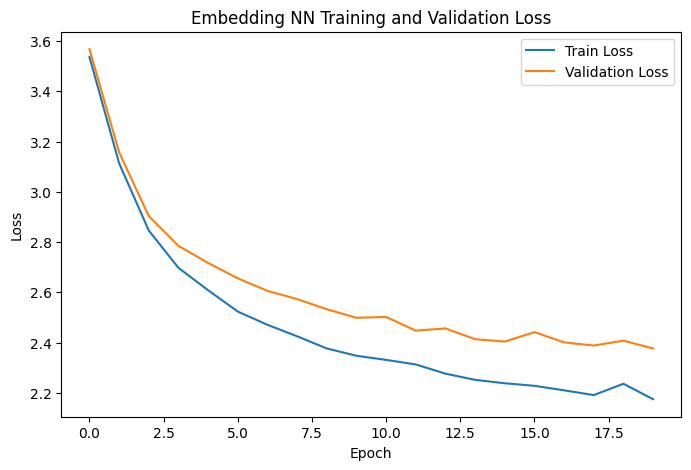

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_nn["train_loss"], label="Train Loss")
plt.plot(history_nn["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Embedding NN Training and Validation Loss")
plt.legend()
plt.show()

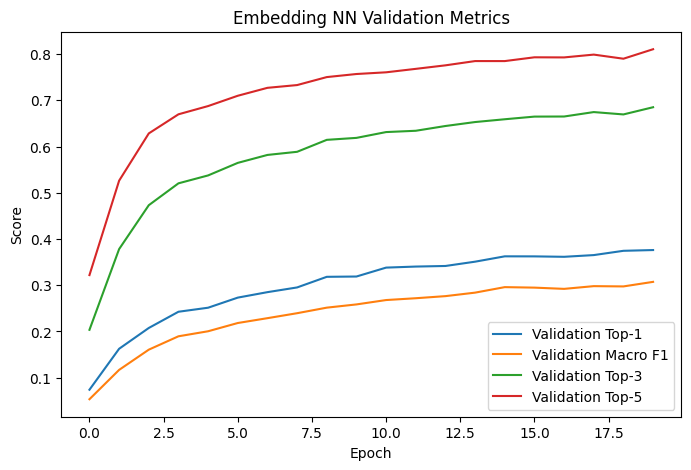

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_nn["val_top1"], label="Validation Top-1")
plt.plot(history_nn["val_macro_f1"], label="Validation Macro F1")
plt.plot(history_nn["val_top3"], label="Validation Top-3")
plt.plot(history_nn["val_top5"], label="Validation Top-5")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Embedding NN Validation Metrics")
plt.legend()
plt.show()

In [ ]:
baseline_results = {
    "Top-1": 0.0928,
    "Macro F1": 0.0636,
    "Top-3": 0.2332,
    "Top-5": 0.3478
}

nn_results = {
    "Top-1": val_top1_nn,
    "Macro F1": val_macro_f1_nn,
    "Top-3": val_top3_nn,
    "Top-5": val_top5_nn
}

print("Baseline vs Embedding NN (Validation)")
for metric in baseline_results:
    print(f"{metric}: baseline={baseline_results[metric]:.4f} | nn={nn_results[metric]:.4f}")

Baseline vs Embedding NN (Validation)
Top-1: baseline=0.0928 | nn=0.3761
Macro F1: baseline=0.0636 | nn=0.3072
Top-3: baseline=0.2332 | nn=0.6850
Top-5: baseline=0.3478 | nn=0.8105


# Hyperparameter tuning

In [ ]:
def run_experiment(picked_train, role_train, side_train, winrate_train, y_train_nn,
                   picked_val, role_val, side_val, winrate_val, y_val_nn,
                   num_champs, num_roles,
                   embed_dim, hidden_dim, learning_rate,
                   epochs=20, batch_size=32, use_class_weights=True, seed=42):

    print(f"\nRunning experiment with: embed_dim={embed_dim}, hidden_dim={hidden_dim}, lr={learning_rate}")
    params, history = train_embedding_nn(
        picked_train, role_train, side_train, winrate_train, y_train_nn,
        picked_val, role_val, side_val, winrate_val, y_val_nn,
        num_champs=num_champs,
        num_roles=num_roles,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        learning_rate=learning_rate,
        epochs=epochs, # Reduce epochs for quicker tuning, can increase later
        batch_size=batch_size,
        use_class_weights=use_class_weights,
        seed=seed
    )
    # Get validation metrics from the last epoch
    val_top1 = history["val_top1"][-1]
    val_macro_f1 = history["val_macro_f1"][-1]
    val_top3 = history["val_top3"][-1]
    val_top5 = history["val_top5"][-1]

    print(f"Experiment results: Val Top1={val_top1:.4f}, Val Macro F1={val_macro_f1:.4f}")
    return {
        "embed_dim": embed_dim,
        "hidden_dim": hidden_dim,
        "learning_rate": learning_rate,
        "val_top1": val_top1,
        "val_macro_f1": val_macro_f1,
        "val_top3": val_top3,
        "val_top5": val_top5,
        "params": params, # Store params if we want to retrieve the best model
        "history": history
    }

In [ ]:
embed_dims = [16, 32]
hidden_dims = [64, 128]
learning_rates = [0.001, 0.0005]

# Store results
all_results = []

# Grid search loop
for ed in embed_dims:
    for hd in hidden_dims:
        for lr in learning_rates:
            result = run_experiment(
                picked_train, role_train, side_train, winrate_train, y_train_nn,
                picked_val, role_val, side_val, winrate_val, y_val_nn,
                num_champs=num_champs,
                num_roles=len(role_to_idx),
                embed_dim=ed,
                hidden_dim=hd,
                learning_rate=lr,
                epochs=10, # Reduce epochs for quicker tuning, can increase later
                batch_size=32,
                use_class_weights=True,
                seed=42
            )
            all_results.append(result)

# Find the best performing model based on validation Top-1 accuracy
best_result = max(all_results, key=lambda x: x['val_top1'])

print("\n--- Best Hyperparameters Found ---")
print(f"Embed Dim: {best_result['embed_dim']}")
print(f"Hidden Dim: {best_result['hidden_dim']}")
print(f"Learning Rate: {best_result['learning_rate']}")
print(f"Validation Top-1 Accuracy: {best_result['val_top1']:.4f}")
print(f"Validation Macro F1: {best_result['val_macro_f1']:.4f}")
print(f"Validation Top-3 Accuracy: {best_result['val_top3']:.4f}")
print(f"Validation Top-5 Accuracy: {best_result['val_top5']:.4f}")

# Optionally, store the best params and history for later use
best_params_nn = best_result['params']
best_history_nn = best_result['history']


Running experiment with: embed_dim=16, hidden_dim=64, lr=0.001
Epoch 1/10 | Train Loss: 3.5361 | Val Loss: 3.5672 | Val Top1: 0.0739 | Val Top3: 0.2035 | Val Top5: 0.3219 | Val Macro F1: 0.0533
Epoch 2/10 | Train Loss: 3.1134 | Val Loss: 3.1571 | Val Top1: 0.1625 | Val Top3: 0.3782 | Val Top5: 0.5261 | Val Macro F1: 0.1168
Epoch 3/10 | Train Loss: 2.8459 | Val Loss: 2.9032 | Val Top1: 0.2075 | Val Top3: 0.4731 | Val Top5: 0.6284 | Val Macro F1: 0.1605
Epoch 4/10 | Train Loss: 2.6974 | Val Loss: 2.7849 | Val Top1: 0.2426 | Val Top3: 0.5204 | Val Top5: 0.6697 | Val Macro F1: 0.1895
Epoch 5/10 | Train Loss: 2.6083 | Val Loss: 2.7167 | Val Top1: 0.2513 | Val Top3: 0.5375 | Val Top5: 0.6875 | Val Macro F1: 0.2004
Epoch 6/10 | Train Loss: 2.5235 | Val Loss: 2.6558 | Val Top1: 0.2732 | Val Top3: 0.5646 | Val Top5: 0.7098 | Val Macro F1: 0.2182
Epoch 7/10 | Train Loss: 2.4708 | Val Loss: 2.6058 | Val Top1: 0.2850 | Val Top3: 0.5818 | Val Top5: 0.7270 | Val Macro F1: 0.2287
Epoch 8/10 | Train 